# 0. Data Normalization Check

Notebook de apoio para validar a qualidade dos dados gerados em Parquet, com foco no escopo atual do projeto:

- integridade da camada `curated`
- consistência mínima para feature engineering
- sinais de qualidade para modelagem supervisionada


In [1]:
# =====================================================
# Setup
# =====================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto a partir do notebook.")

BASE_DIR = find_project_root(Path.cwd())

flights_path = BASE_DIR / "data" / "curated" / "flights" / "flights.parquet"
airports_path = BASE_DIR / "data" / "curated" / "airports" / "airports.parquet"
airlines_path = BASE_DIR / "data" / "curated" / "airlines" / "airlines.parquet"
features_path = BASE_DIR / "data" / "features" / "flights_features.parquet"

for path in [flights_path, airports_path, airlines_path, features_path]:
    print(f"{path.name}: {'OK' if path.exists() else 'MISSING'} -> {path}")

flights.parquet: OK -> c:\FIAP\EML\WORKSPACES\workspace-techchallenger\fiap-eml-tech-challenge-fase-3\data\curated\flights\flights.parquet
airports.parquet: OK -> c:\FIAP\EML\WORKSPACES\workspace-techchallenger\fiap-eml-tech-challenge-fase-3\data\curated\airports\airports.parquet
airlines.parquet: OK -> c:\FIAP\EML\WORKSPACES\workspace-techchallenger\fiap-eml-tech-challenge-fase-3\data\curated\airlines\airlines.parquet
flights_features.parquet: OK -> c:\FIAP\EML\WORKSPACES\workspace-techchallenger\fiap-eml-tech-challenge-fase-3\data\features\flights_features.parquet


In [2]:
# =====================================================
# Load dos datasets
# =====================================================

flights = pd.read_parquet(flights_path)
airports = pd.read_parquet(airports_path)
airlines = pd.read_parquet(airlines_path)
features = pd.read_parquet(features_path) if features_path.exists() else None

print("Flights:", flights.shape)
print("Airports:", airports.shape)
print("Airlines:", airlines.shape)
print("Features:", features.shape if features is not None else "nao gerado")

Flights: (5819079, 49)
Airports: (322, 7)
Airlines: (14, 2)
Features: (5819079, 54)


## 1. Visão estrutural

A ideia aqui é validar se os arquivos foram gerados com o schema esperado, sem colunas vazias acidentais e sem perda evidente de linhas.

In [3]:
def dataset_overview(df, name):
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "nulls": df.isna().sum().values,
        "null_pct": (df.isna().mean().values * 100).round(2),
        "unique": df.nunique(dropna=False).values,
    })
    print(f"\n{name} -> linhas={len(df):,} | colunas={df.shape[1]}")
    return summary.sort_values(["null_pct", "unique"], ascending=[False, False])

overview_flights = dataset_overview(flights, "flights.parquet")
overview_airports = dataset_overview(airports, "airports.parquet")
overview_airlines = dataset_overview(airlines, "airlines.parquet")

overview_flights


flights.parquet -> linhas=5,819,079 | colunas=49

airports.parquet -> linhas=322 | colunas=7

airlines.parquet -> linhas=14 | colunas=2


,column,dtype,non_null,nulls,null_pct,unique
29,DELAY_RATIO,float64,5819079,0,0.0,63075
4,FLIGHT_NUMBER,Int32,5819079,0,0.0,6952
8,DEPARTURE_TIME,Int32,5819079,0,0.0,1440
11,WHEELS_OFF,Int32,5819079,0,0.0,1440
16,WHEELS_ON,Int32,5819079,0,0.0,1440
19,ARRIVAL_TIME,Int32,5819079,0,0.0,1440
18,SCHEDULED_ARRIVAL,Int32,5819079,0,0.0,1435
15,DISTANCE,float32,5819079,0,0.0,1363
7,SCHEDULED_DEPARTURE,Int32,5819079,0,0.0,1321
20,ARRIVAL_DELAY,float32,5819079,0,0.0,1240


In [4]:
print("Top colunas com maior percentual de nulos em flights:")
display(overview_flights.head(15))

print("Schema resumido de airports:")
display(overview_airports)

print("Schema resumido de airlines:")
display(overview_airlines)

Top colunas com maior percentual de nulos em flights:


,column,dtype,non_null,nulls,null_pct,unique
29,DELAY_RATIO,float64,5819079,0,0.0,63075
4,FLIGHT_NUMBER,Int32,5819079,0,0.0,6952
8,DEPARTURE_TIME,Int32,5819079,0,0.0,1440
11,WHEELS_OFF,Int32,5819079,0,0.0,1440
16,WHEELS_ON,Int32,5819079,0,0.0,1440
19,ARRIVAL_TIME,Int32,5819079,0,0.0,1440
18,SCHEDULED_ARRIVAL,Int32,5819079,0,0.0,1435
15,DISTANCE,float32,5819079,0,0.0,1363
7,SCHEDULED_DEPARTURE,Int32,5819079,0,0.0,1321
20,ARRIVAL_DELAY,float32,5819079,0,0.0,1240


Schema resumido de airports:


,column,dtype,non_null,nulls,null_pct,unique
5,LATITUDE,float64,319,3,0.93,320
6,LONGITUDE,float64,319,3,0.93,320
0,IATA_CODE,string,322,0,0.00,322
1,AIRPORT,string,322,0,0.00,322
2,CITY,string,322,0,0.00,308
3,STATE,string,322,0,0.00,54
4,COUNTRY,string,322,0,0.00,1


Schema resumido de airlines:


,column,dtype,non_null,nulls,null_pct,unique
0,IATA_CODE,string,14,0,0.0,14
1,AIRLINE,string,14,0,0.0,14


## 2. Regras básicas de qualidade

Essas checagens atacam o que mais importa no momento: duplicidade, domínio de colunas críticas e faixas plausíveis após a normalização.

In [5]:
quality_checks = {
    "rows_flights": len(flights),
    "duplicate_rows_flights": int(flights.duplicated().sum()),
    "null_year": int(flights["YEAR"].isna().sum()) if "YEAR" in flights.columns else None,
    "null_month": int(flights["MONTH"].isna().sum()) if "MONTH" in flights.columns else None,
    "null_day": int(flights["DAY"].isna().sum()) if "DAY" in flights.columns else None,
    "invalid_month": int((~flights["MONTH"].between(1, 12)).fillna(False).sum()) if "MONTH" in flights.columns else None,
    "invalid_day": int((~flights["DAY"].between(1, 31)).fillna(False).sum()) if "DAY" in flights.columns else None,
    "invalid_day_of_week": int((~flights["DAY_OF_WEEK"].between(1, 7)).fillna(False).sum()) if "DAY_OF_WEEK" in flights.columns else None,
    "cancelled_not_binary": int((~flights["CANCELLED"].isin([0, 1])).fillna(False).sum()) if "CANCELLED" in flights.columns else None,
    "diverted_not_binary": int((~flights["DIVERTED"].isin([0, 1])).fillna(False).sum()) if "DIVERTED" in flights.columns else None,
}

pd.DataFrame(list(quality_checks.items()), columns=["check", "value"])

,check,value
0,rows_flights,5819079
1,duplicate_rows_flights,0
2,null_year,0
3,null_month,0
4,null_day,0
5,invalid_month,0
6,invalid_day,0
7,invalid_day_of_week,0
8,cancelled_not_binary,0
9,diverted_not_binary,0


In [6]:
time_cols = [
    "SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "WHEELS_OFF",
    "WHEELS_ON", "SCHEDULED_ARRIVAL", "ARRIVAL_TIME"
]

time_quality = []
for col in time_cols:
    if col in flights.columns:
        series = pd.to_numeric(flights[col], errors="coerce")
        invalid = ((series < 0) | (series > 2359)).fillna(False).sum()
        time_quality.append({
            "column": col,
            "nulls": int(series.isna().sum()),
            "invalid_hhmm_range": int(invalid),
            "min": float(series.min()) if series.notna().any() else np.nan,
            "max": float(series.max()) if series.notna().any() else np.nan,
        })

pd.DataFrame(time_quality)

,column,nulls,invalid_hhmm_range,min,max
0,SCHEDULED_DEPARTURE,0,0,1.0,1439.0
1,DEPARTURE_TIME,0,0,0.0,1439.0
2,WHEELS_OFF,0,0,0.0,1439.0
3,WHEELS_ON,0,0,0.0,1439.0
4,SCHEDULED_ARRIVAL,0,0,0.0,1439.0
5,ARRIVAL_TIME,0,0,0.0,1439.0


## 3. Distribuições críticas para o escopo atual

Aqui o objetivo é detectar distorções óbvias depois da normalização e antes de seguir para modelagem.

,count,mean,std,min,25%,50%,75%,max
DEPARTURE_DELAY,5819079.0,9.194586,36.723713,-82.0,-5.000000,-1.000000,7.000000,1988.0
ARRIVAL_DELAY,5819079.0,4.327482,38.919559,-87.0,-13.000000,-5.000000,7.000000,1971.0
SCHEDULED_TIME,5819079.0,141.685745,75.210678,0.0,85.000000,123.000000,173.000000,718.0
ELAPSED_TIME,5819079.0,134.532379,75.767090,0.0,81.000000,117.000000,167.000000,766.0
AIR_TIME,5819079.0,111.462029,73.154213,0.0,59.000000,93.000000,143.000000,690.0
DISTANCE,5819079.0,0.161499,0.122488,0.0,0.070939,0.126159,0.209794,1.0


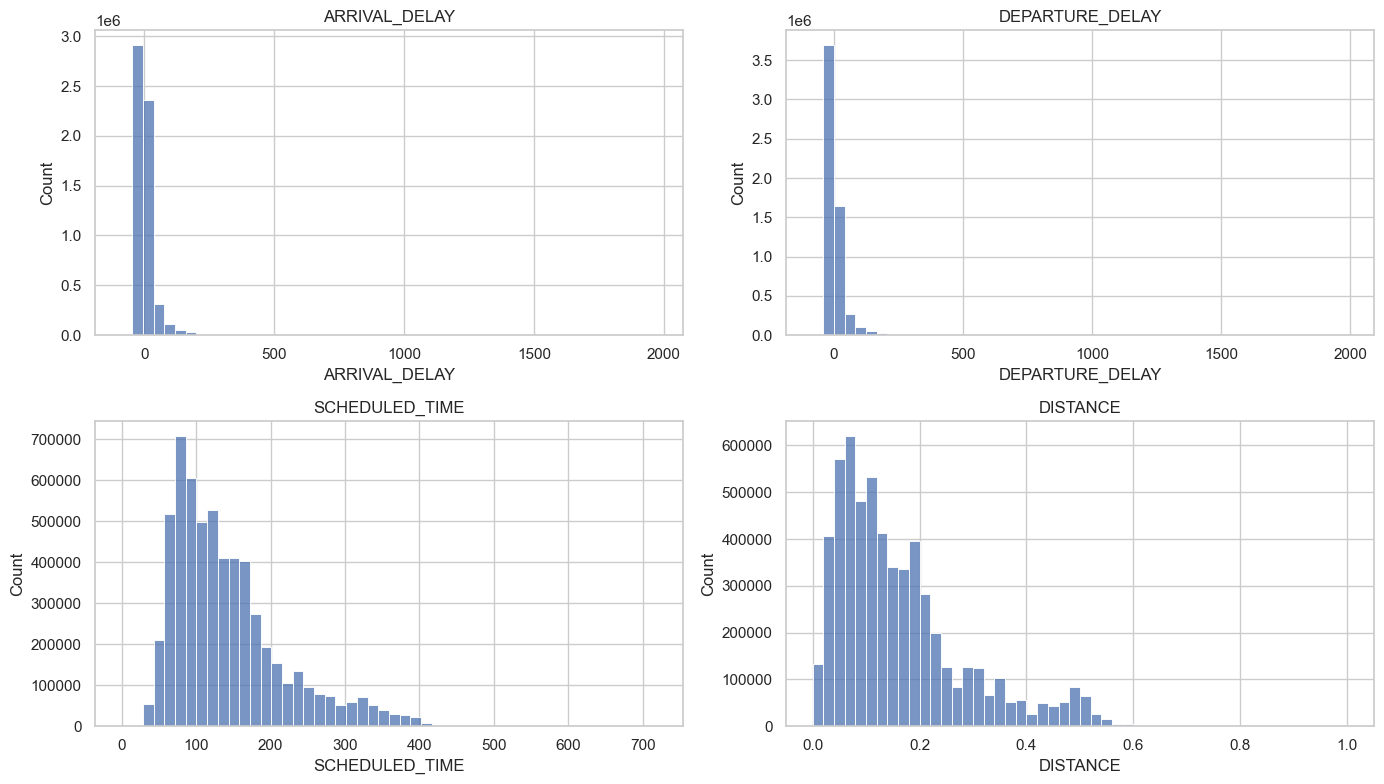

In [7]:
numeric_focus = [
    "DEPARTURE_DELAY", "ARRIVAL_DELAY", "SCHEDULED_TIME",
    "ELAPSED_TIME", "AIR_TIME", "DISTANCE"
]

available_numeric_focus = [col for col in numeric_focus if col in flights.columns]
display(flights[available_numeric_focus].describe().T)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

plot_cols = [col for col in ["ARRIVAL_DELAY", "DEPARTURE_DELAY", "SCHEDULED_TIME", "DISTANCE"] if col in flights.columns]

for ax, col in zip(axes, plot_cols):
    sns.histplot(flights[col].dropna(), bins=50, ax=ax, kde=False)
    ax.set_title(col)

for idx in range(len(plot_cols), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [8]:
categorical_focus = [col for col in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CANCELLATION_REASON"] if col in flights.columns]

for col in categorical_focus:
    print(f"\nTop categorias: {col}")
    display(flights[col].value_counts(dropna=False).head(15).to_frame("count"))


Top categorias: ORIGIN_AIRPORT


,count
ORIGIN_AIRPORT,
326,346836
534,285884
392,239551
391,196055
482,194673
584,148008
545,146815
457,146622
480,133181



Top categorias: DESTINATION_AIRPORT


,count
DESTINATION_AIRPORT,
327,346904
535,285906
393,239582
392,196010
483,194696
585,147966
546,146812
458,146683
481,133198


## 4. Outliers e relações úteis

Essas visões ajudam a perceber se o dado está plausível para responder perguntas do projeto sobre atraso, aeroportos críticos e padrões operacionais.

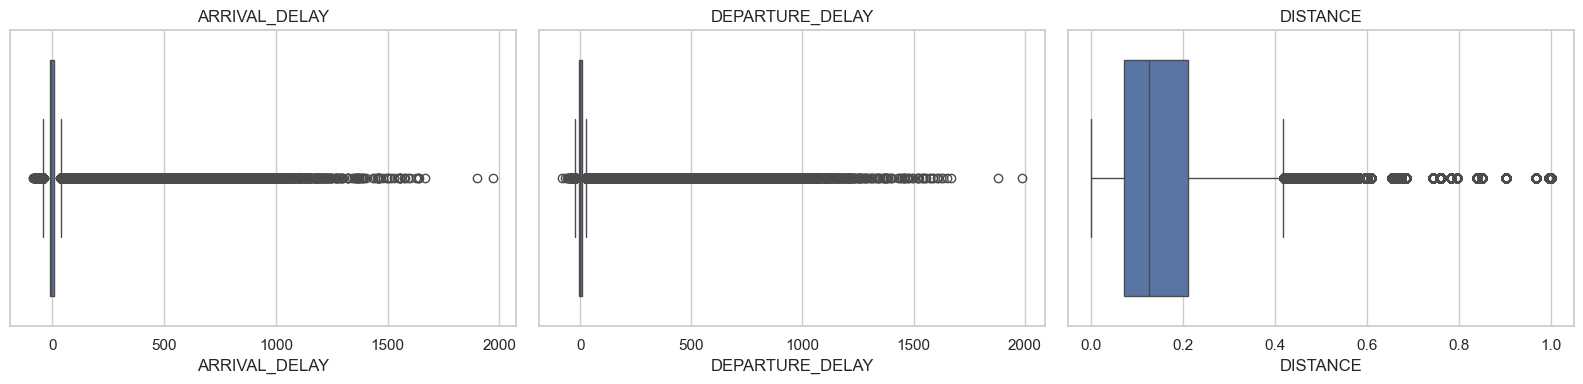

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if "ARRIVAL_DELAY" in flights.columns:
    sns.boxplot(x=flights["ARRIVAL_DELAY"], ax=axes[0])
    axes[0].set_title("ARRIVAL_DELAY")

if "DEPARTURE_DELAY" in flights.columns:
    sns.boxplot(x=flights["DEPARTURE_DELAY"], ax=axes[1])
    axes[1].set_title("DEPARTURE_DELAY")

if "DISTANCE" in flights.columns:
    sns.boxplot(x=flights["DISTANCE"], ax=axes[2])
    axes[2].set_title("DISTANCE")

plt.tight_layout()
plt.show()

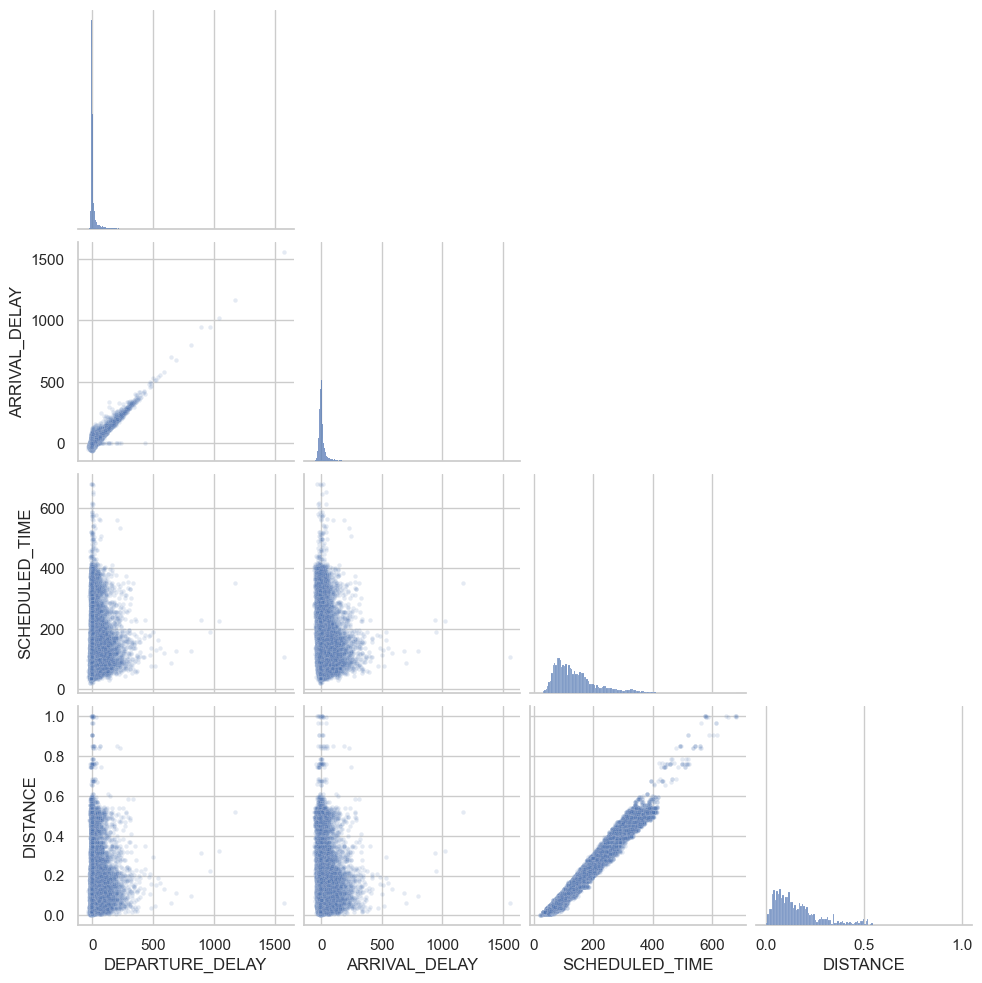

In [10]:
sample = flights.sample(min(len(flights), 50000), random_state=42).copy()
scatter_cols = [col for col in ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "SCHEDULED_TIME", "DISTANCE"] if col in sample.columns]

if len(scatter_cols) >= 2:
    sns.pairplot(sample[scatter_cols].dropna(), corner=True, plot_kws={"alpha": 0.15, "s": 10})
    plt.show()

## 5. Consistência entre `curated` e `features`

Como o escopo atual já inclui feature engineering e modelagem, esta parte verifica se a camada de features preserva volume, target e atributos derivados esperados.

In [11]:
if features is not None:
    consistency = {
        "flights_rows": len(flights),
        "features_rows": len(features),
        "same_row_count": len(flights) == len(features),
        "features_has_target": "IS_DELAYED" in features.columns,
        "features_has_route": "ROUTE" in features.columns,
        "features_has_period": "PERIOD_OF_DAY" in features.columns,
        "features_has_city": "CITY" in features.columns,
        "features_has_state": "STATE" in features.columns,
    }
    display(pd.DataFrame(list(consistency.items()), columns=["check", "value"]))
    
    expected_feature_cols = [
        "IS_DELAYED", "DEPARTURE_HOUR", "IS_WEEKEND",
        "PERIOD_OF_DAY", "ROUTE", "CITY", "STATE"
    ]
    print("\nColunas esperadas na camada features:")
    display(pd.DataFrame({
        "column": expected_feature_cols,
        "exists": [col in features.columns for col in expected_feature_cols]
    }))

    print("\nNulos nas colunas mais relevantes de features:")
    cols = [col for col in expected_feature_cols if col in features.columns]
    display((features[cols].isna().sum().to_frame("nulls").assign(null_pct=lambda x: (x["nulls"] / len(features) * 100).round(2))))
else:
    print("Arquivo de features ainda nao foi gerado.")

,check,value
0,flights_rows,5819079
1,features_rows,5819079
2,same_row_count,True
3,features_has_target,True
4,features_has_route,True
5,features_has_period,True
6,features_has_city,True
7,features_has_state,True



Colunas esperadas na camada features:


,column,exists
0,IS_DELAYED,True
1,DEPARTURE_HOUR,True
2,IS_WEEKEND,True
3,PERIOD_OF_DAY,True
4,ROUTE,True
5,CITY,True
6,STATE,True



Nulos nas colunas mais relevantes de features:


,nulls,null_pct
IS_DELAYED,0,0.0
DEPARTURE_HOUR,0,0.0
IS_WEEKEND,0,0.0
PERIOD_OF_DAY,0,0.0
ROUTE,0,0.0
CITY,0,0.0
STATE,0,0.0


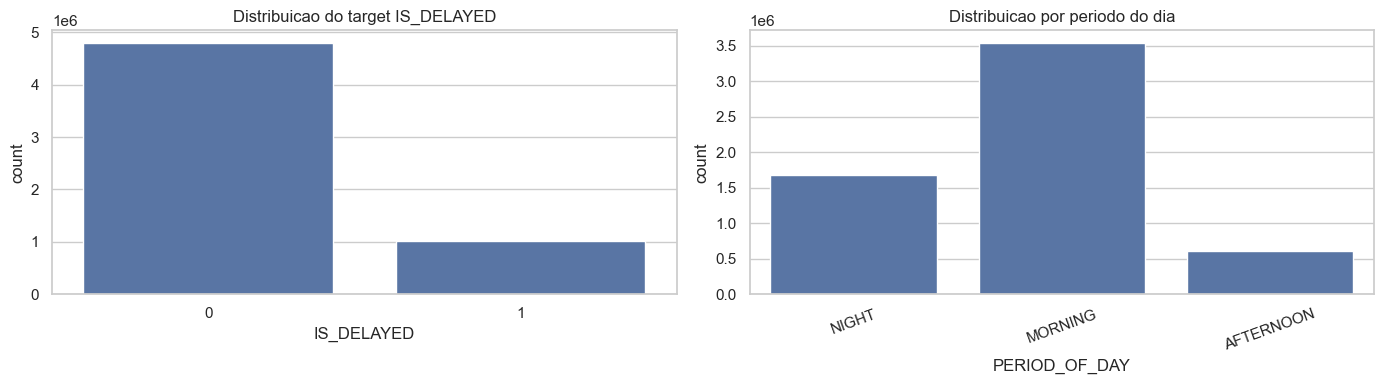

Top aeroportos de origem por volume:


,count
ORIGIN_AIRPORT,
326,346836
534,285884
392,239551
391,196055
482,194673
584,148008
545,146815
457,146622
480,133181


In [12]:
if features is not None and "IS_DELAYED" in features.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.countplot(data=features, x="IS_DELAYED", ax=axes[0])
    axes[0].set_title("Distribuicao do target IS_DELAYED")

    if "PERIOD_OF_DAY" in features.columns:
        order = [col for col in ["NIGHT", "MORNING", "AFTERNOON", "EVENING", "UNKNOWN"] if col in features["PERIOD_OF_DAY"].astype(str).unique()]
        sns.countplot(data=features, x="PERIOD_OF_DAY", order=order, ax=axes[1])
        axes[1].set_title("Distribuicao por periodo do dia")
        axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

    print("Top aeroportos de origem por volume:")
    if "ORIGIN_AIRPORT" in features.columns:
        display(features["ORIGIN_AIRPORT"].value_counts().head(15).to_frame("count"))

## 6. Checklist final de aprovação

Se esta etapa estiver saudável, o esperado é:

- arquivos Parquet existentes e legíveis
- volume de linhas consistente entre `flights` e `features`
- colunas críticas com tipos coerentes
- poucos nulos fora das colunas naturalmente incompletas de atraso
- sem explosão de duplicidade
- features derivadas presentes para a próxima etapa de modelagem


## 7. Pontos críticos identificados

Esta visão final resume automaticamente os principais riscos observados nas etapas anteriores. A ideia é transformar o diagnóstico em leitura executiva para decidir se o pipeline pode seguir para modelagem ou se precisa de correção antes.

In [13]:
critical_points = []

def add_critical_point(severity, topic, evidence, recommendation):
    critical_points.append({
        "severity": severity,
        "topic": topic,
        "evidence": evidence,
        "recommendation": recommendation,
    })

duplicate_rows = int(flights.duplicated().sum())
if duplicate_rows > 0:
    add_critical_point(
        "high",
        "Duplicidade em flights",
        f"Foram encontradas {duplicate_rows:,} linhas duplicadas em flights.parquet.",
        "Validar a origem da duplicidade e decidir entre deduplicacao tecnica ou regra de negocio antes do treino."
    )

high_null_cols = overview_flights[overview_flights["null_pct"] > 20]
if not high_null_cols.empty:
    cols = ", ".join(high_null_cols["column"].head(8).tolist())
    add_critical_point(
        "high",
        "Colunas com alto volume de nulos",
        f"As colunas com mais nulos em flights incluem: {cols}.",
        "Separar nulos esperados por regra operacional de nulos problematicos e definir estrategia explicita de imputacao ou descarte."
    )

invalid_month = int((~flights["MONTH"].between(1, 12)).fillna(False).sum()) if "MONTH" in flights.columns else 0
invalid_day = int((~flights["DAY"].between(1, 31)).fillna(False).sum()) if "DAY" in flights.columns else 0
invalid_dow = int((~flights["DAY_OF_WEEK"].between(1, 7)).fillna(False).sum()) if "DAY_OF_WEEK" in flights.columns else 0

if invalid_month + invalid_day + invalid_dow > 0:
    add_critical_point(
        "high",
        "Inconsistencia em calendario",
        f"Foram encontrados MONTH invalidos={invalid_month}, DAY invalidos={invalid_day}, DAY_OF_WEEK invalidos={invalid_dow}.",
        "Revisar a etapa de normalizacao antes de usar atributos temporais em analises ou features."
    )

time_issues = []
for col in ["SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "WHEELS_OFF", "WHEELS_ON", "SCHEDULED_ARRIVAL", "ARRIVAL_TIME"]:
    if col in flights.columns:
        series = pd.to_numeric(flights[col], errors="coerce")
        invalid = int(((series < 0) | (series > 2359)).fillna(False).sum())
        if invalid > 0:
            time_issues.append(f"{col}={invalid:,}")

if time_issues:
    add_critical_point(
        "medium",
        "Horarios fora da faixa esperada",
        "Ocorrencias invalidas detectadas em: " + ", ".join(time_issues),
        "Verificar se os horarios deveriam estar em HHMM ou minutos e padronizar a validacao conforme a camada analisada."
    )

if features is None:
    add_critical_point(
        "high",
        "Camada de features ausente",
        "O arquivo flights_features.parquet nao foi encontrado.",
        "Executar o pipeline de feature engineering antes da validacao final para modelagem."
    )
else:
    if len(flights) != len(features):
        add_critical_point(
            "high",
            "Divergencia de volume entre curated e features",
            f"flights possui {len(flights):,} linhas e features possui {len(features):,} linhas.",
            "Investigar perdas ou duplicacoes geradas no merge com airports e na criacao de features."
        )

    expected_feature_cols = ["IS_DELAYED", "DEPARTURE_HOUR", "IS_WEEKEND", "PERIOD_OF_DAY", "ROUTE", "CITY", "STATE"]
    missing_feature_cols = [col for col in expected_feature_cols if col not in features.columns]
    if missing_feature_cols:
        add_critical_point(
            "high",
            "Features esperadas ausentes",
            "Colunas nao encontradas: " + ", ".join(missing_feature_cols),
            "Revisar a etapa build_features.py e garantir contrato minimo para treinamento e analise."
        )

    if "IS_DELAYED" in features.columns:
        target_dist = features["IS_DELAYED"].value_counts(normalize=True, dropna=False)
        minority_ratio = float(target_dist.min()) if len(target_dist) > 1 else 0.0
        if minority_ratio < 0.1:
            add_critical_point(
                "medium",
                "Desbalanceamento do target",
                f"A menor classe de IS_DELAYED representa {minority_ratio:.2%} do dataset.",
                "Considerar estratificacao, metricas robustas e tecnicas de balanceamento antes de comparar modelos."
            )

    if "CITY" in features.columns and "STATE" in features.columns:
        city_unknown = int(features["CITY"].astype(str).eq("UNKNOWN").sum())
        state_unknown = int(features["STATE"].astype(str).eq("UNKNOWN").sum())
        if city_unknown > 0 or state_unknown > 0:
            add_critical_point(
                "medium",
                "Enriquecimento incompleto com aeroportos",
                f"CITY=UNKNOWN em {city_unknown:,} linhas e STATE=UNKNOWN em {state_unknown:,} linhas.",
                "Validar chave de merge entre airports.IATA_CODE e ORIGIN_AIRPORT para evitar perda de contexto geografico."
            )

if not critical_points:
    add_critical_point(
        "low",
        "Nenhum ponto critico relevante",
        "As verificacoes principais nao encontraram anomalias relevantes para o escopo atual.",
        "Seguir para modelagem mantendo monitoramento de metricas e validacao amostral."
    )

critical_df = pd.DataFrame(critical_points)
severity_order = pd.CategoricalDtype(categories=["high", "medium", "low"], ordered=True)
critical_df["severity"] = critical_df["severity"].astype(severity_order)
critical_df = critical_df.sort_values(["severity", "topic"]).reset_index(drop=True)

display(critical_df)

print("\nResumo executivo:")
for _, row in critical_df.iterrows():
    print(f"- [{str(row['severity']).upper()}] {row['topic']}: {row['evidence']}")


,severity,topic,evidence,recommendation
0,medium,Enriquecimento incompleto com aeroportos,"CITY=UNKNOWN em 5,819,079 linhas e STATE=UNKNO...",Validar chave de merge entre airports.IATA_COD...



Resumo executivo:
- [MEDIUM] Enriquecimento incompleto com aeroportos: CITY=UNKNOWN em 5,819,079 linhas e STATE=UNKNOWN em 5,819,079 linhas.
